Closest y to 0.3: 0.299329 (points: 120)


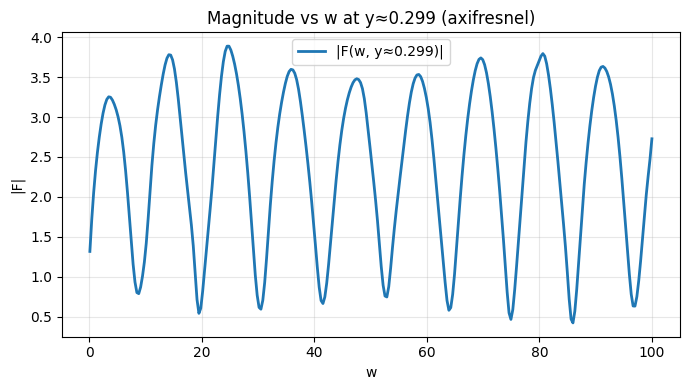

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from pathlib import Path

# Load data from axifresnel.out
base_dir = Path.cwd().parent
axifresnel_path = base_dir / "axifresnel.out"
if not axifresnel_path.exists():
    raise FileNotFoundError(f"Missing {axifresnel_path}")

data = np.loadtxt(axifresnel_path)
w = data[:, 0]
y = data[:, 1]
re_f = data[:, 2]
im_f = data[:, 3]
mag_f = np.hypot(re_f, im_f)

# Find closest y value to target
target_y = 0.3
closest_y = y[np.abs(y - target_y).argmin()]
mask = np.isclose(y, closest_y, rtol=1e-6, atol=0.0)
print(f"Closest y to {target_y}: {closest_y:.6f} (points: {mask.sum()})")

w_slice = w[mask]
mag_slice = mag_f[mask]
order = np.argsort(w_slice)
w_sorted = w_slice[order]
mag_sorted = mag_slice[order]

# Fit spline to data (s=smoothing factor; adjust as needed)
spline = UnivariateSpline(w_sorted, mag_sorted, s=1e-3, k=3)
w_smooth = np.linspace(w_sorted.min(), w_sorted.max(), 300)
mag_smooth = spline(w_smooth)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(w_smooth, mag_smooth, "-", linewidth=2, label=f"|F(w, y≈{closest_y:.3f})|", color="C0")
ax.set_xlabel("w")
ax.set_ylabel("|F|")
ax.set_title(f"Magnitude vs w at y≈{closest_y:.3f} (axifresnel)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("fresnely0.297.pdf", bbox_inches="tight")
plt.show()

Data grid-compatible? True (w: 120, y: 150, N: 18000)


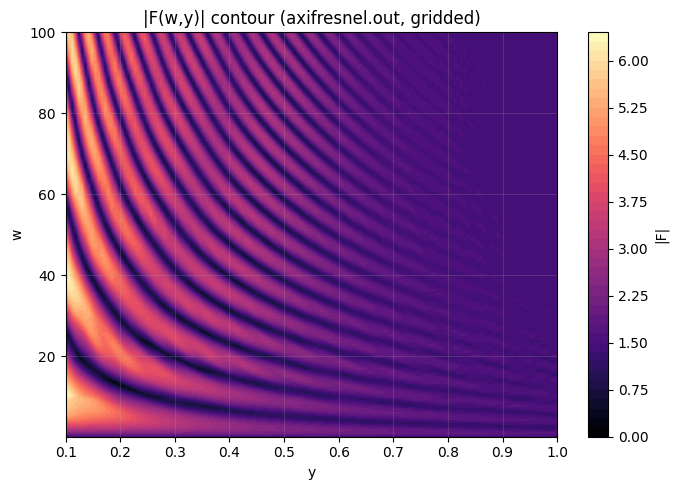

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from pathlib import Path

# Contour plot of |F(w,y)| from axifresnel.out

# Load data from axifresnel.out
base_dir = Path.cwd().parent
axifresnel_path = base_dir / "axifresnel.out"
if not axifresnel_path.exists():
    raise FileNotFoundError(f"Missing {axifresnel_path}")

data = np.loadtxt(axifresnel_path)
w = data[:, 0]
y = data[:, 1]
re_f = data[:, 2]
im_f = data[:, 3]
amp = np.hypot(re_f, im_f)

unique_w = np.unique(w)
unique_y = np.unique(y)
N = len(w)

fig, ax = plt.subplots(figsize=(7, 5))
levels = 60

# Try gridded contour first by sorting and reshaping
can_grid = len(unique_w) * len(unique_y) == N
print(f"Data grid-compatible? {can_grid} (w: {len(unique_w)}, y: {len(unique_y)}, N: {N})")

if can_grid:
    # Sort by w then y to create w-major grid
    idx = np.lexsort((y, w))
    w_sorted = w[idx]
    y_sorted = y[idx]
    amp_sorted = amp[idx]

    try:
        Amp = amp_sorted.reshape(len(unique_w), len(unique_y))
        # Build coordinate grids
        W, Y = np.meshgrid(unique_w, unique_y, indexing="ij")
        cs = ax.contourf(Y, W, Amp, levels=levels, cmap="magma")
        cbar = fig.colorbar(cs, ax=ax, label="|F|")
        ax.set_title("|F(w,y)| contour (axifresnel.out, gridded)")
    except ValueError as e:
        print(f"Grid reshape failed: {e}; falling back to triangulation")
        tri = mtri.Triangulation(y, w)
        cs = ax.tricontourf(tri, amp, levels=levels, cmap="magma")
        cbar = fig.colorbar(cs, ax=ax, label="|F|")
        ax.set_title("|F(w,y)| contour (axifresnel.out, triangulated)")
else:
    # Use triangulation for scattered data
    tri = mtri.Triangulation(y, w)
    cs = ax.tricontourf(tri, amp, levels=levels, cmap="magma")
    cbar = fig.colorbar(cs, ax=ax, label="|F|")
    ax.set_title("|F(w,y)| contour (axifresnel.out, triangulated)")

ax.set_xlabel("y")
ax.set_ylabel("w")
ax.grid(True, alpha=0.2)


plt.tight_layout()
plt.savefig("fresnelwy.pdf", bbox_inches="tight")
plt.show()

In [ ]:
import numpy as np
from pathlib import Path

# Generate GL files for n_gl = 3000, 4000, 6000, 7000, 8000, 9000
sizes = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
output_dir = Path("/Users/kamion/SCIENCE/FastHankelTransform/FHT_parallel")

for n_gl in sizes:
    print(f"Generating {n_gl} Gauss-Legendre points...")
    roots, weights = np.polynomial.legendre.leggauss(n_gl)
    
    output_path = output_dir / f"gl{n_gl}"
    with output_path.open("w") as f:
        for root, weight in zip(roots, weights):
            f.write(f"{root:.16e} {weight:.16e}\n")
    
    file_size_mb = output_path.stat().st_size / (1024**2)
    print(f"  ✓ Saved to {output_path.name} ({file_size_mb:.1f} MB)")

print("\nAll GL files generated successfully!")
print(f"Files created: gl3000, gl4000, gl6000, gl7000, gl8000, gl9000")

Generating 3000 Gauss-Legendre points...
  ✓ Saved to gl3000 (0.1 MB)
Generating 4000 Gauss-Legendre points...
  ✓ Saved to gl4000 (0.2 MB)
Generating 6000 Gauss-Legendre points...
  ✓ Saved to gl6000 (0.3 MB)
Generating 7000 Gauss-Legendre points...
  ✓ Saved to gl7000 (0.3 MB)
Generating 8000 Gauss-Legendre points...
  ✓ Saved to gl8000 (0.4 MB)
Generating 9000 Gauss-Legendre points...
  ✓ Saved to gl9000 (0.4 MB)

All GL files generated successfully!
Files created: gl3000, gl4000, gl6000, gl7000, gl8000, gl9000
